# Crop phenology by class: three seasons of Sentinel-2 and Sentinel-1 over Estonia

**Thesis.** *Geospatial Foundation Models for Transparent Agricultural Monitoring under Label-Scarce Conditions*, David Reyes, ITC, University of Twente.

**What this shows.** Notebooks 04 and 05 follow single parcels. This follows **classes**. For each of the 10 main Estonian crops of the thesis class scheme, many parcels are reduced to one curve per season, so the figures describe the crop rather than one field. Both sensors are plotted separately: Sentinel-2 vegetation indices and Sentinel-1 radar backscatter.

**Three seasons, one of them labelled.** 2020, 2021 and 2022 are built, and EuroCrops declares **2021 only**. A parcel declared winter wheat in 2021 grew something else in 2020 and something else again in 2022 wherever rotation applies. The off-year curves are therefore not "the crop in another year"; they are what those fields did, and the distance between them and the 2021 curve measures **how far a 2021 label travels**. That is the question Phase 1 has to answer before imagery from any other year, or an annual embedding, is used against these labels.

**Method.** 580 parcels in 12 windows of 4.48 km, drawn so that each window carries as many classes as possible and the windows sit at least 25 km apart. Every acquisition between YYYY-03-01 and YYYY-11-15 is reduced over each parcel polygon at 20 m, Sentinel-2 after the processing-baseline offset and the scene-classification screening of `gfm4agri.data.sentinel`, Sentinel-1 in linear power with the per-track offset removed per parcel. Per-parcel series go onto a 10-day grid; each class then takes the median across its parcels, and the band is the interquartile range across parcels.

Produced by `results/eda/eurocrops/_class_phenology.py`. One read serves every parcel in a window, which is what makes 580 parcels across three seasons and two sensors affordable; the per-parcel reductions are cached under `data/eurocrops/phenology/`.

## 0. Setup

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)


def find_repo(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "CLAUDE.md").exists() or (p / ".git").exists():
            return p
    raise RuntimeError("repository root not found")


REPO = find_repo(Path.cwd().resolve())
EDA = REPO / "results" / "eda" / "eurocrops"
FIG = EDA / "figures" / "phenology"
CACHE = EDA / "cache"

phenology = json.loads((EDA / "phenology.json").read_text())
sample = pd.read_parquet(CACHE / "phenology_sample.parquet")
s2 = pd.read_parquet(CACHE / "phenology_s2_curves.parquet")
s1 = pd.read_parquet(CACHE / "phenology_s1_curves.parquet")
show = lambda name, width=1150: display(Image(filename=str(FIG / name), width=width))

print(f"{len(sample):,} parcels, {sample['crop'].nunique()} classes, "
      f"{phenology['n_windows']} windows, seasons {phenology['years']}")

580 parcels, 10 classes, 12 windows, seasons [2020, 2021, 2022]


## 1. The sample

A class curve is only as general as the landscape it was measured in, so the geography comes first. The windows are spread across the Estonian declared area rather than concentrated in one county, and each was chosen for class diversity, because a window that is entirely grassland costs a full read and returns one curve.

The class sizes are uneven and stay uneven: grassland contributes 91 parcels and potatoes 17. That is the EuroCrops distribution rather than a sampling choice, and every panel below states its own **n**.

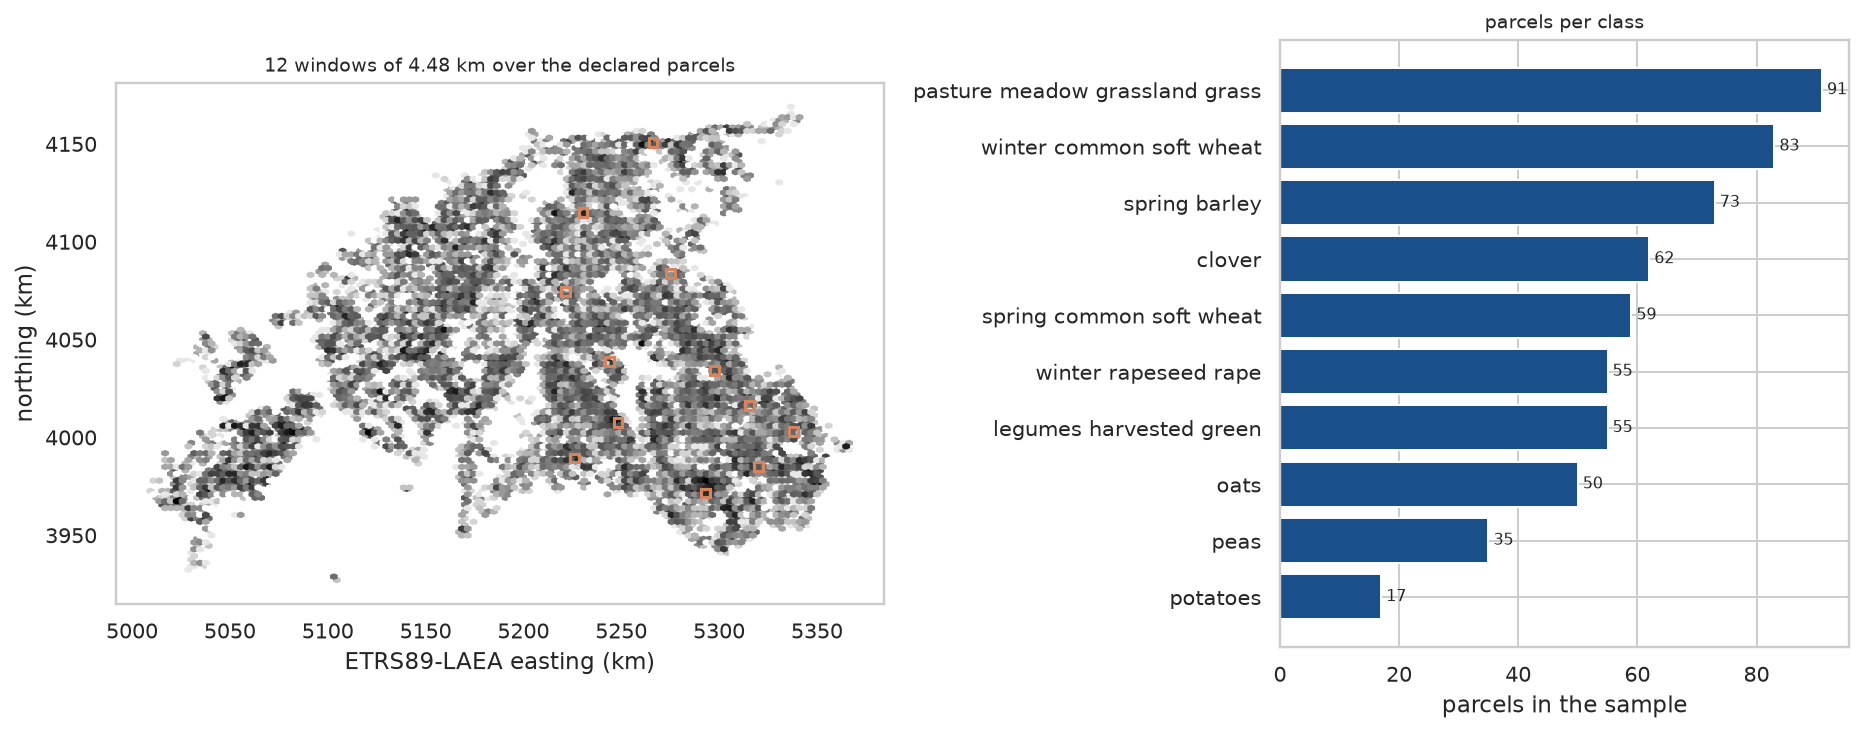

,parcels,median_ha,windows
crop,,,
pasture meadow grassland grass,91,4.793797,12
winter common soft wheat,83,7.735654,12
spring barley,73,6.565365,12
clover,62,2.793759,12
spring common soft wheat,59,5.159798,12
legumes harvested green,55,4.464025,12
winter rapeseed rape,55,7.398939,12
oats,50,7.658467,12
peas,35,6.224615,12


In [2]:
show("00_sample_windows.png", width=1150)
display(sample.groupby("crop").agg(parcels=("parcel_id", "size"),
                                   median_ha=("area_ha", "median"),
                                   windows=("window", "nunique")).sort_values("parcels",
                                                                              ascending=False))

## 2. Sentinel-2

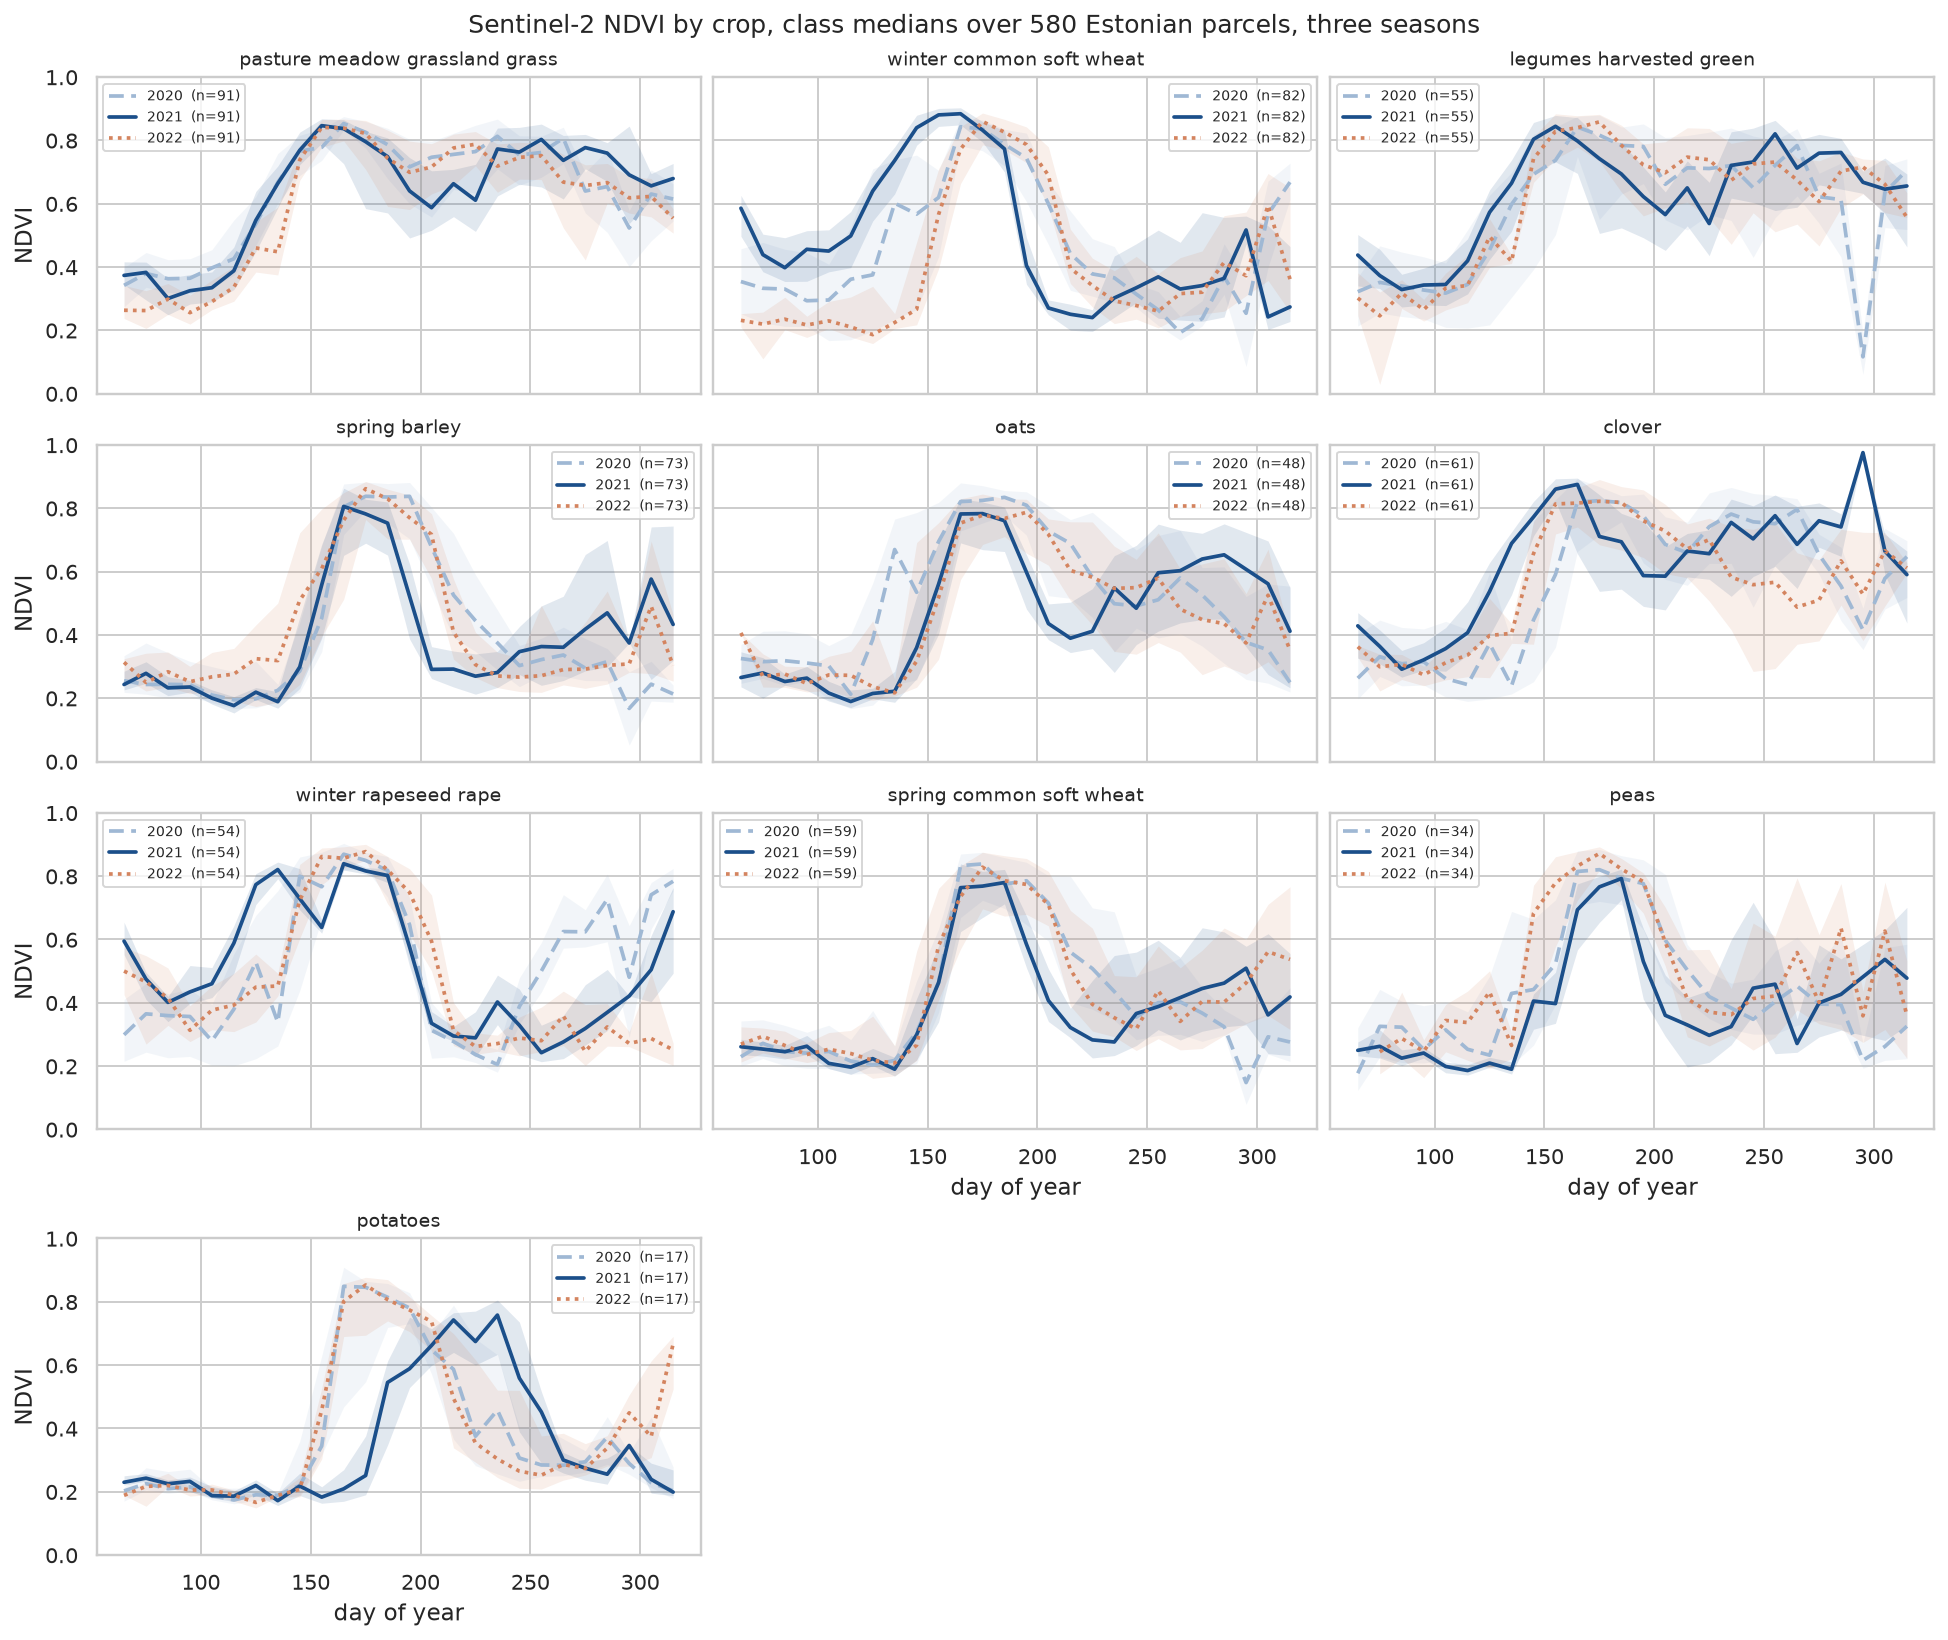

In [3]:
show("01_s2_ndvi_by_crop.png", width=1250)

### 2.1 The declaration year behaves as agronomy says it should

Read the solid dark line in each panel, which is 2021.

The order of green-up is the whole story. Winter rapeseed and winter wheat cross NDVI 0.5 on day 65, having been sown the previous autumn. Grassland, clover and legumes follow on day 125, the spring cereals on day 155 to 165, and potatoes last on day 185. That is a 120-day spread, and it is far larger than any difference in how green the crops become. Winter wheat peaks at 0.88 near day 165 and then falls through ripening and harvest, while potatoes hold a late canopy and peak at 0.76 near day 235. Grassland has no single peak at all: it is green from the first observation to the last, interrupted rather than shaped.

This is the class-level version of what notebook 04 showed on single parcels, and it is the first check that the sampling and the reduction are sound: if the median over dozens of parcels did not reproduce the textbook order of green-up, something would be wrong upstream.

**What separates the classes is mostly timing.** Spring barley, oats and spring wheat reach similar peak values; they differ in when they reach them. A representation that blurs a two-week difference, whether a monthly composite or an annual embedding, removes the signal that distinguishes them, and no encoder recovers it afterwards.

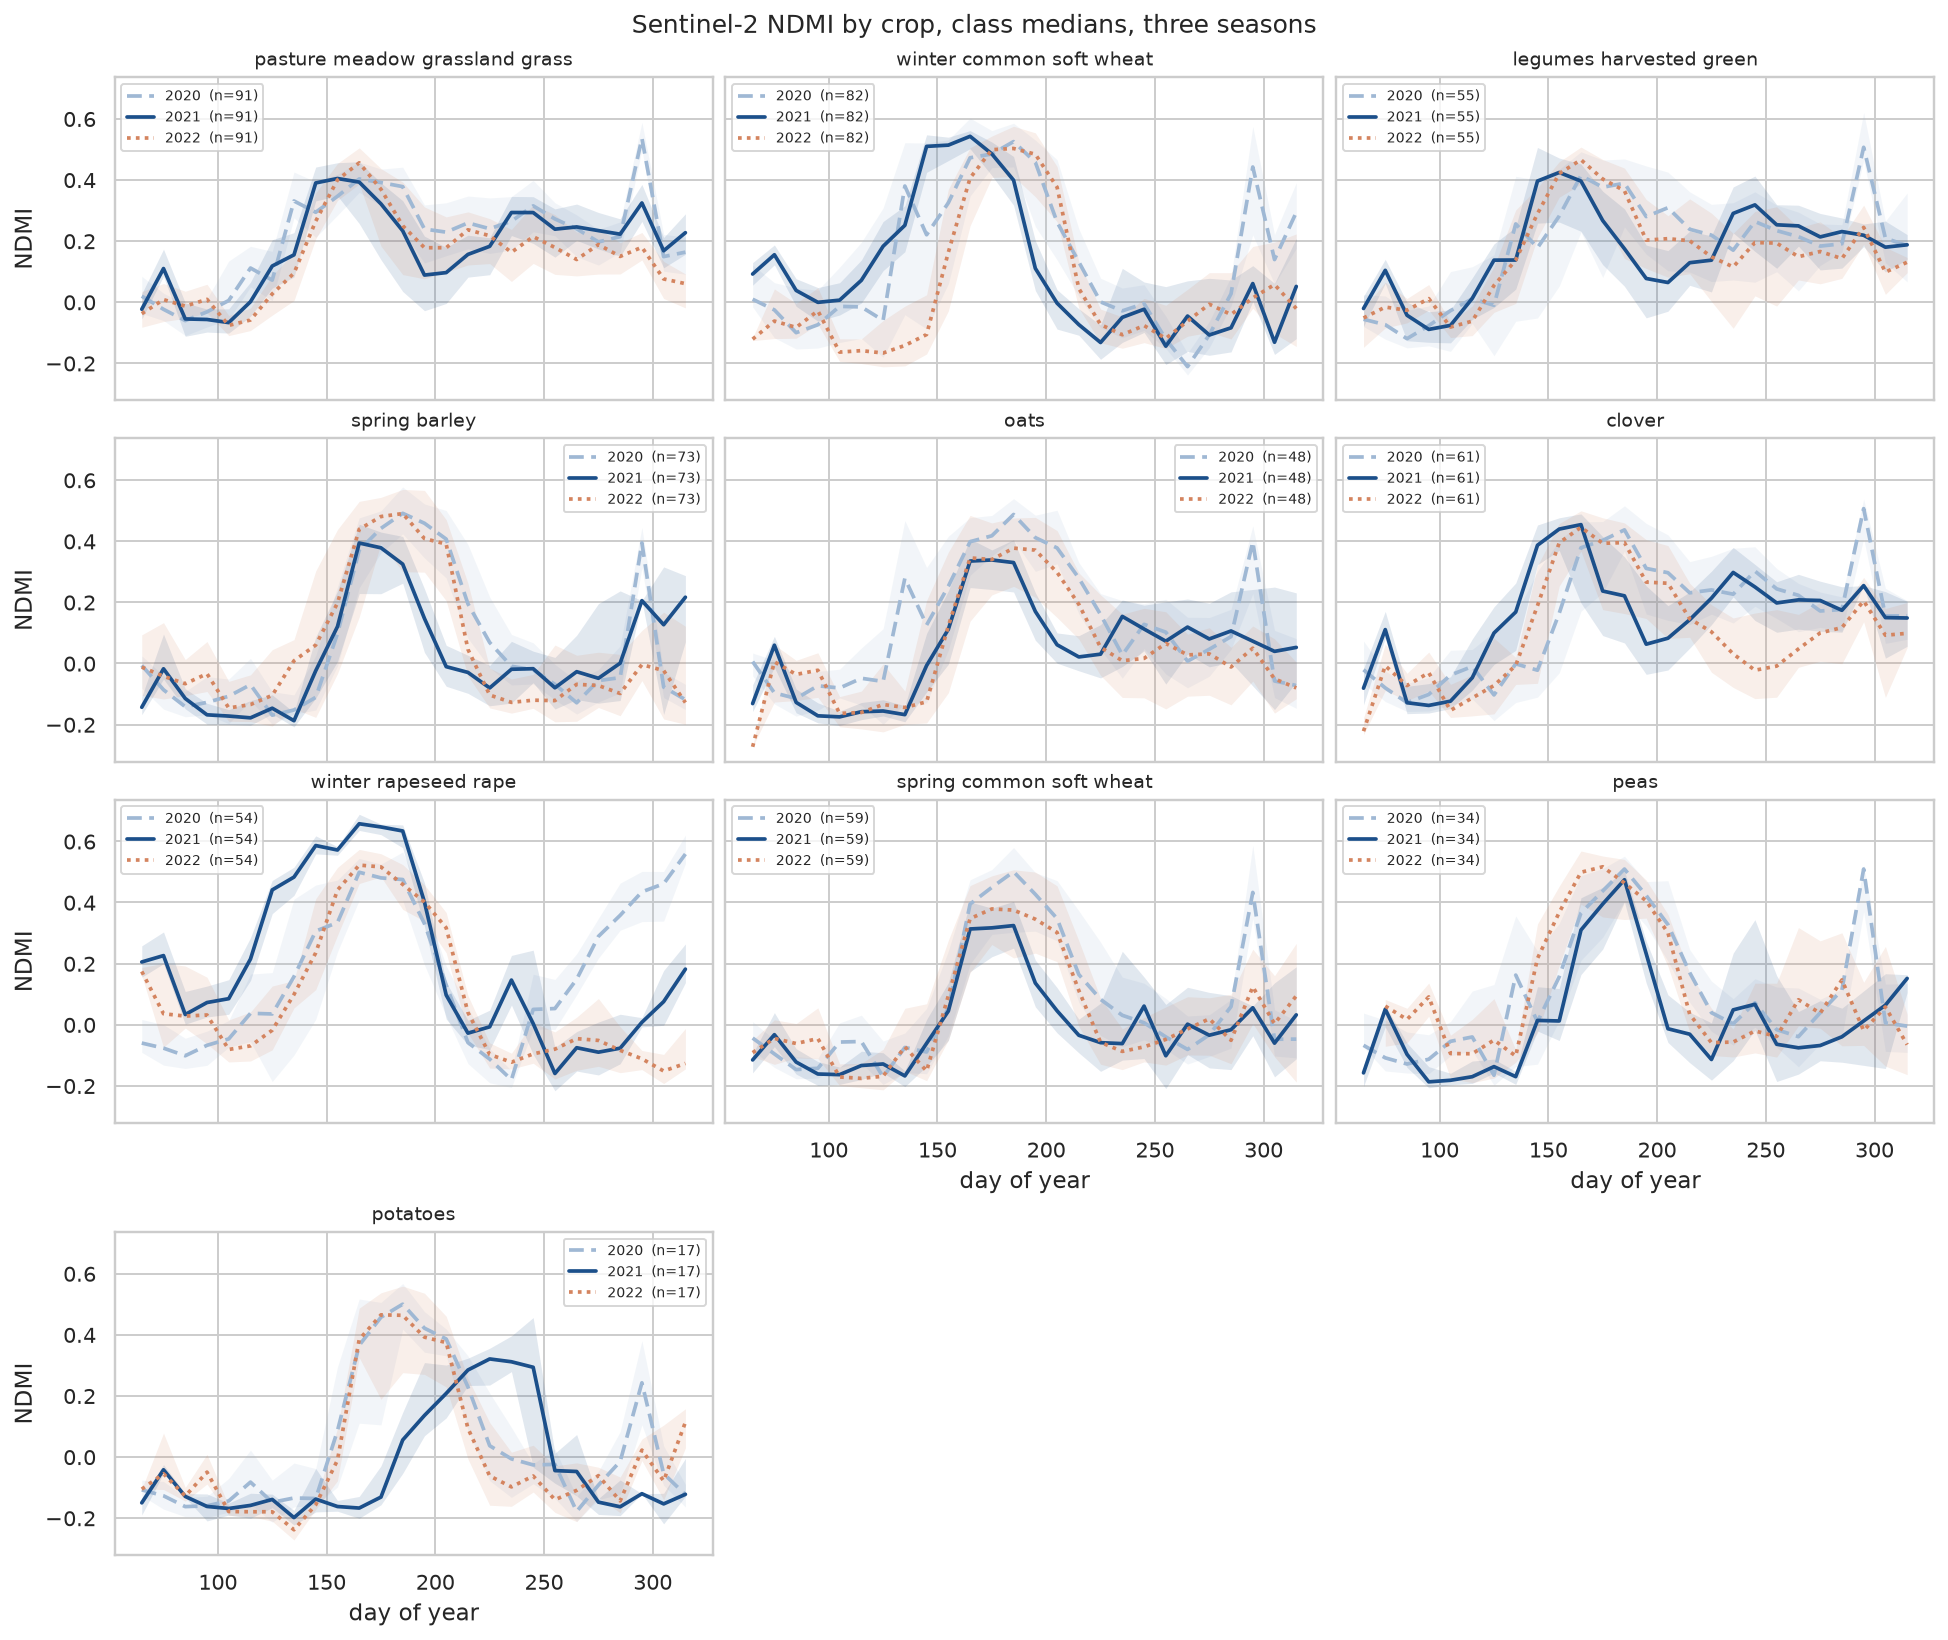

In [4]:
show("02_s2_ndmi_by_crop.png", width=1250)

### 2.2 NDMI carries the harvest more sharply than NDVI

NDMI is canopy water. It falls earlier and further than NDVI at senescence, because a ripening crop loses water before it loses greenness, and the step at harvest is cleaner. For the raw-feature baseline of Phase 1 this matters: a phenometric set computed on NDVI alone places the end of season later than a water index would, and the two give different answers for the same field.

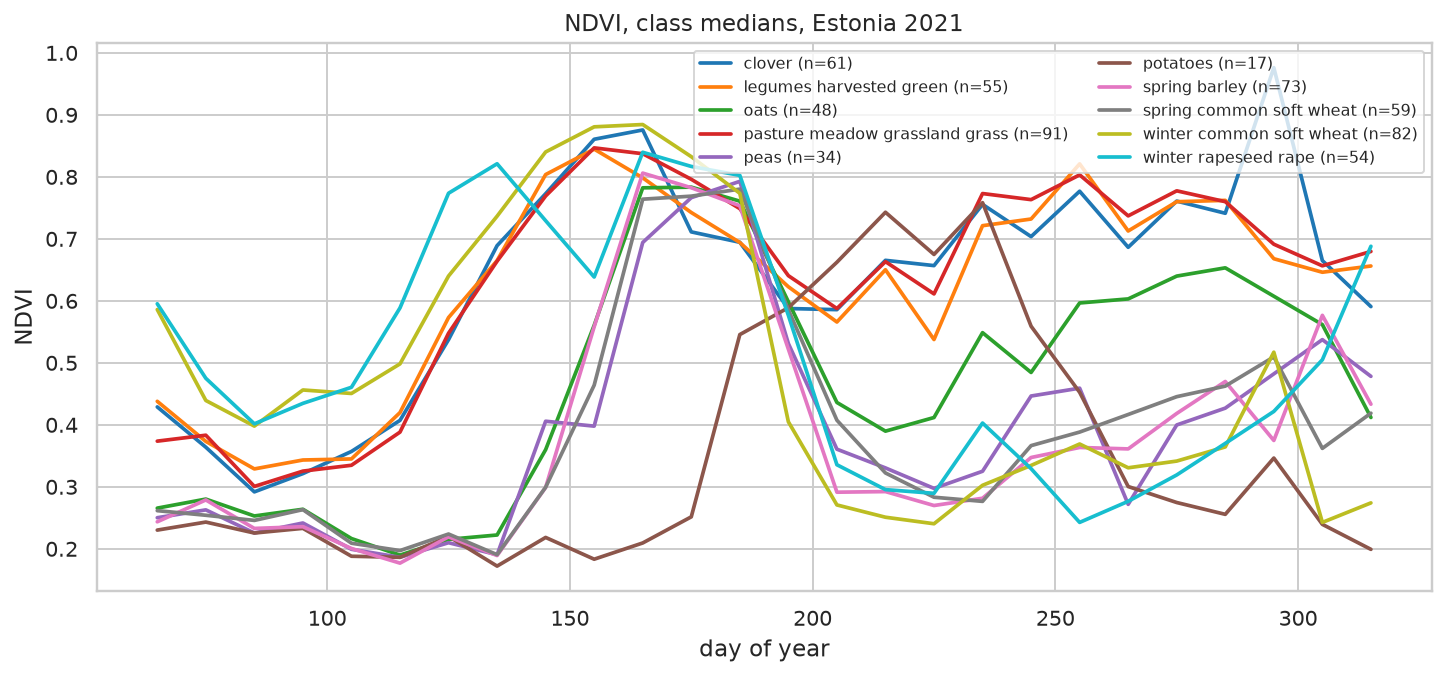

In [5]:
show("03_s2_overview_2021.png", width=1100)

### 2.3 All classes on one axis, 2021

With every class on one axis the separability question becomes concrete. The winter crops occupy the early season alone, the spring cereals form a tight bundle that peaks together, and grassland and clover sit above everything from midsummer on. Classes that overlap here are the ones a classifier will confuse, and the overlap is temporal rather than spectral.

## 3. Sentinel-1

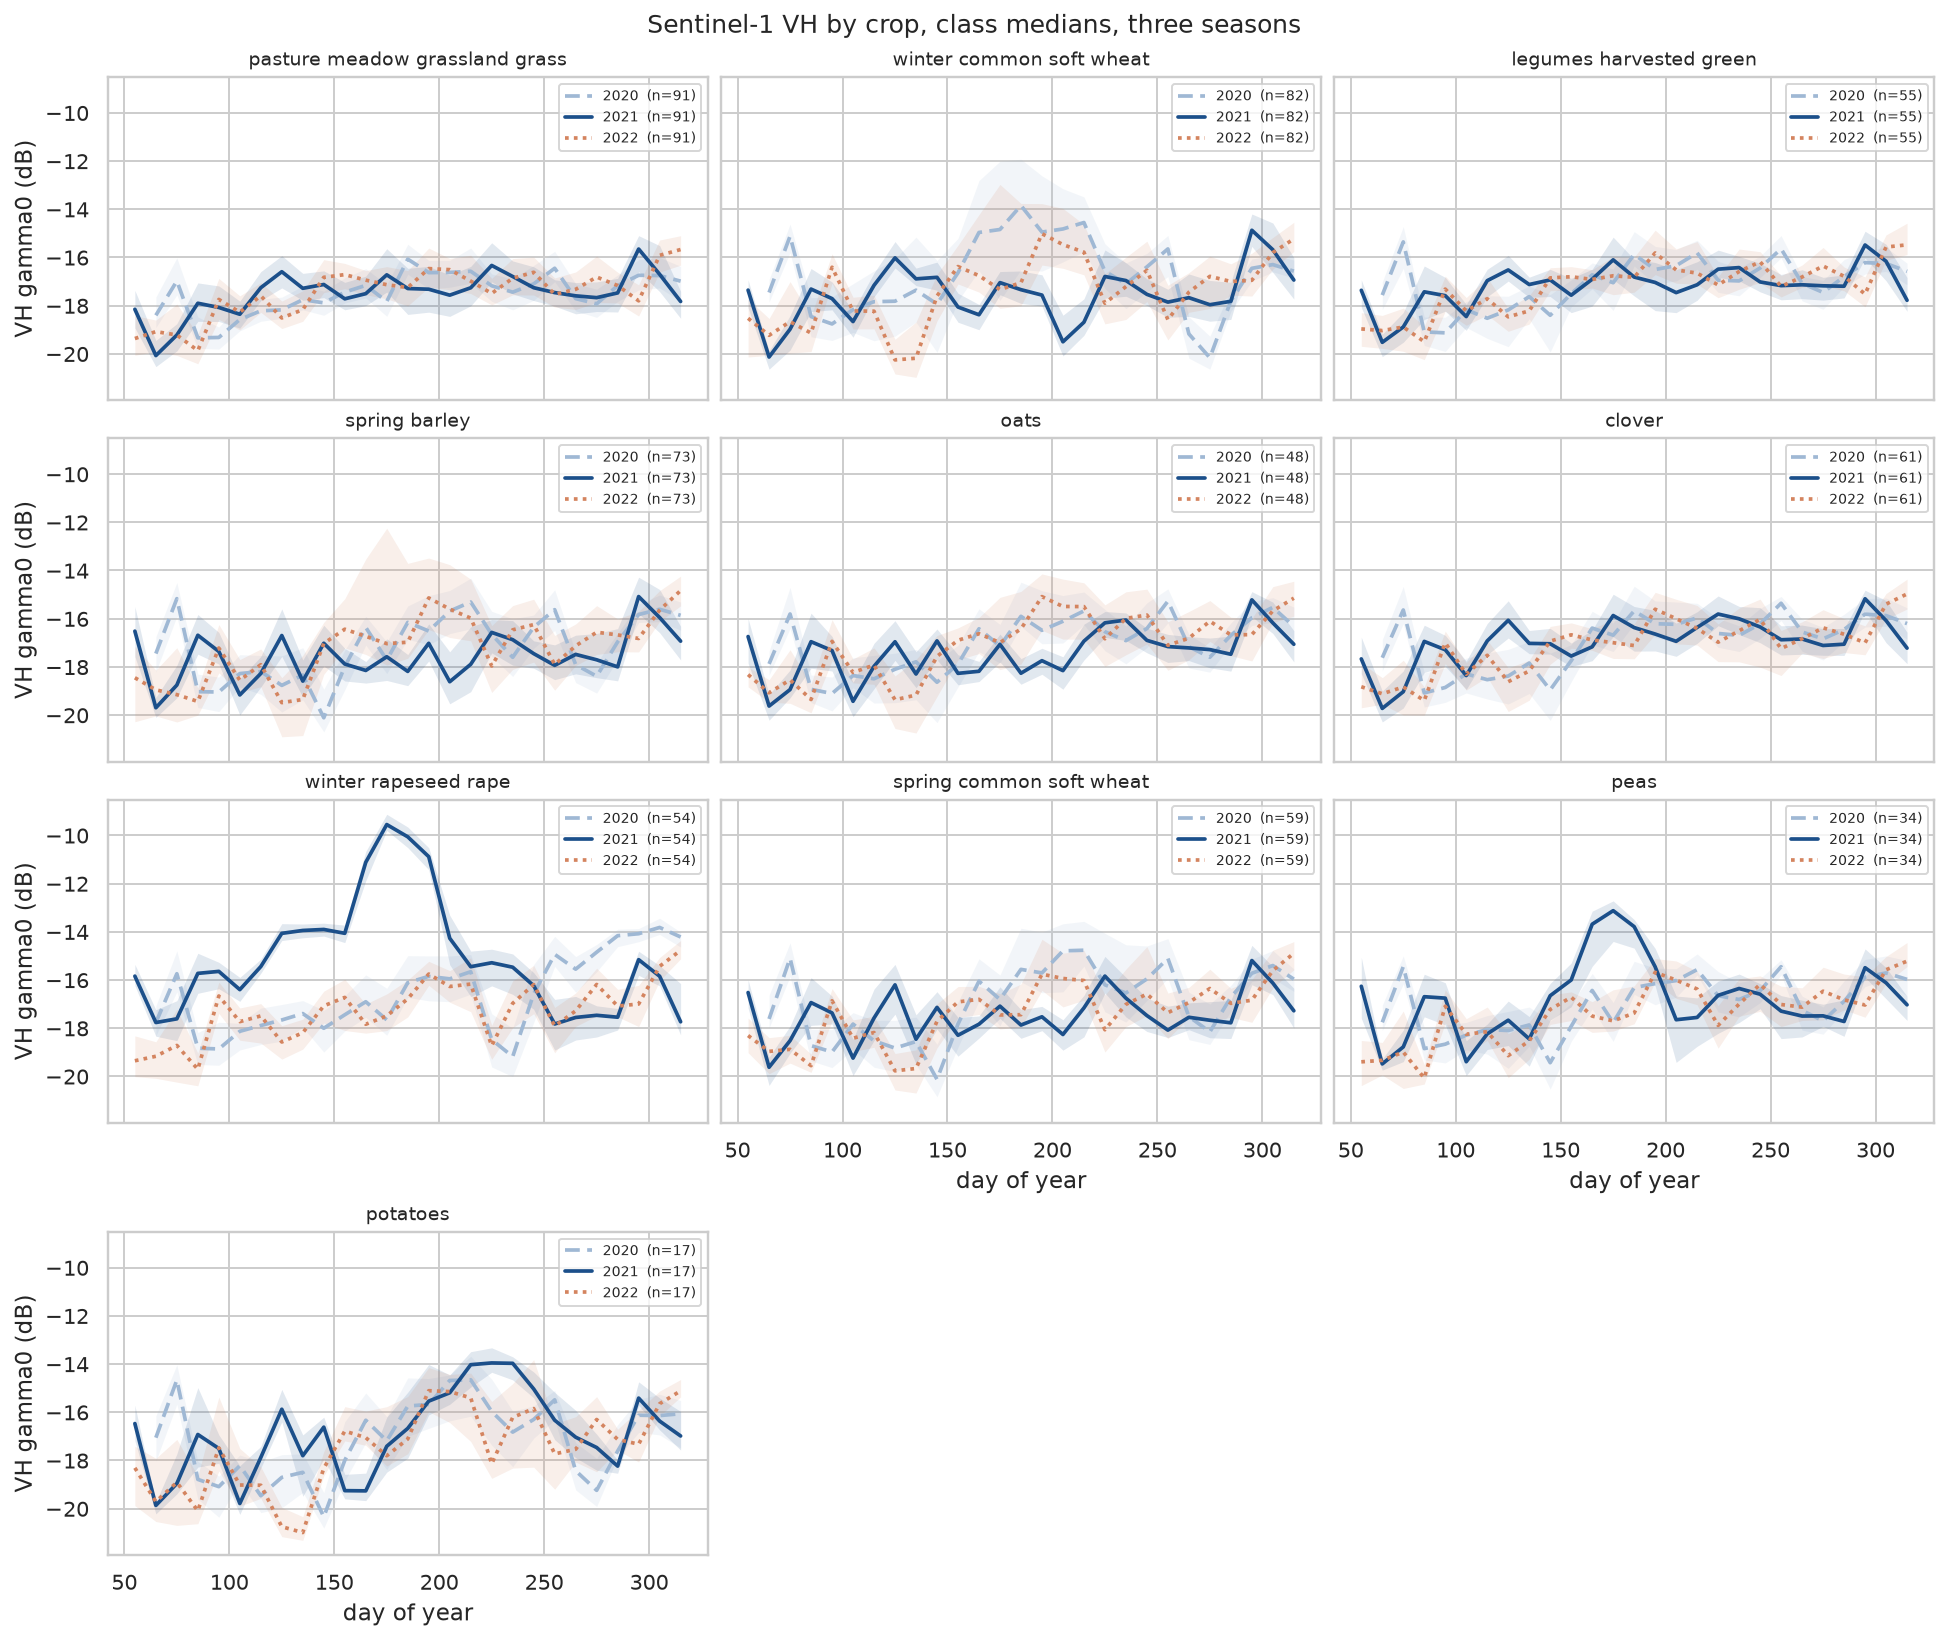

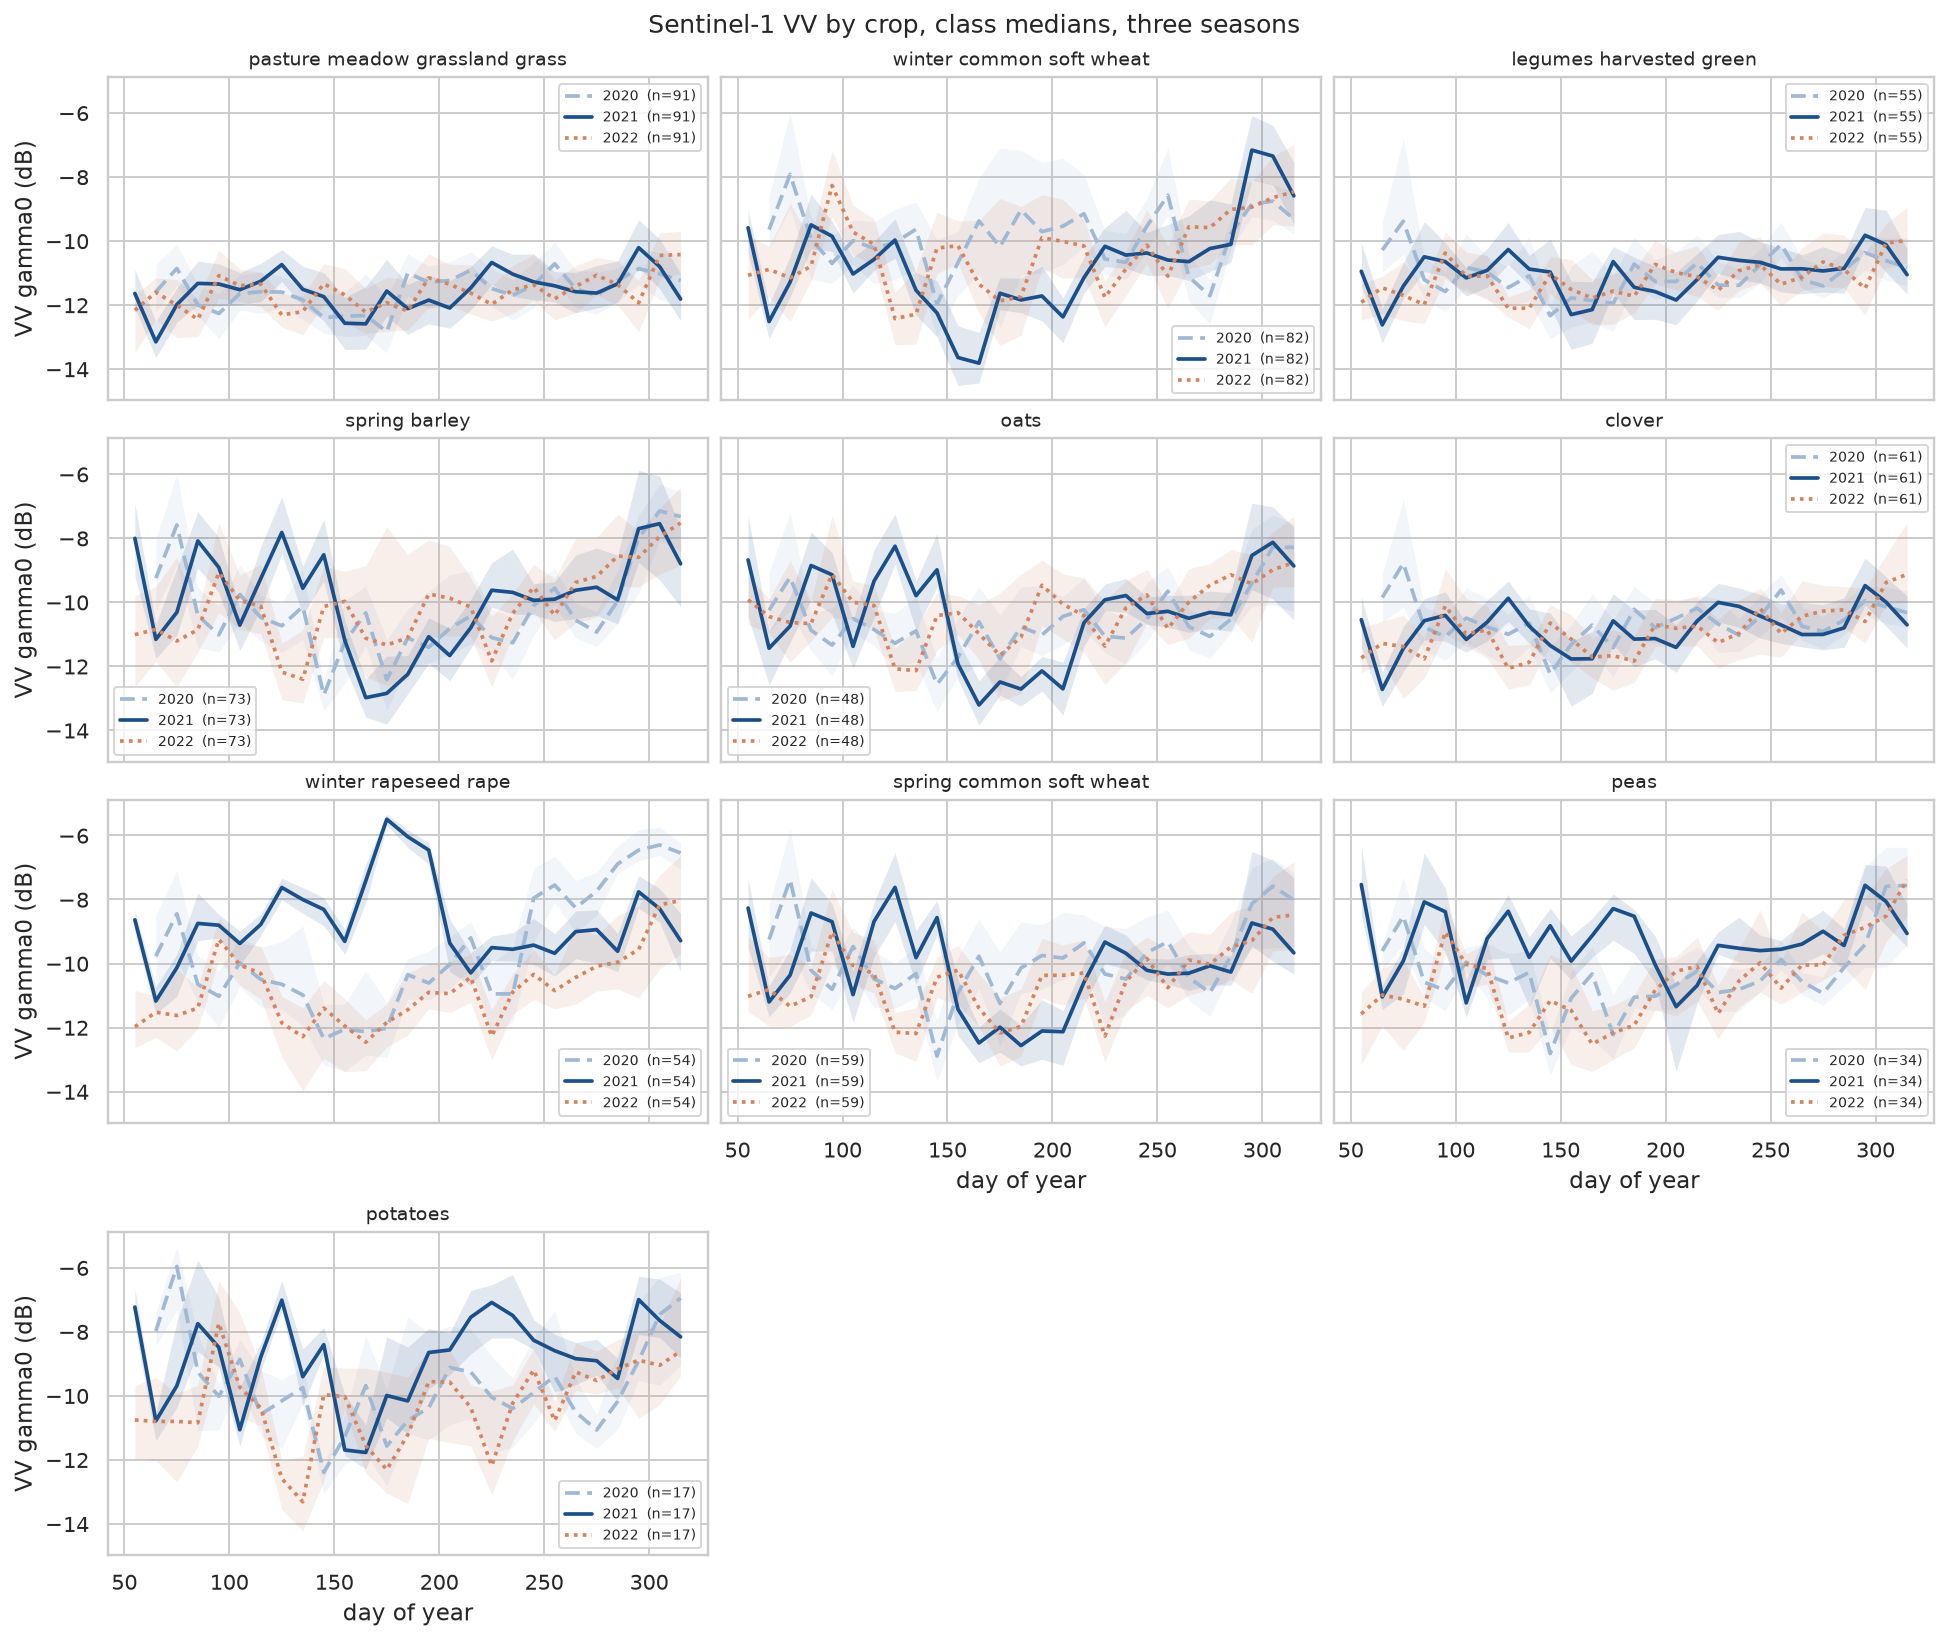

In [6]:
show("04_s1_vh_by_crop.png", width=1250)
show("06_s1_vv_by_crop.png", width=1250)

### 3.1 Radar sees structure, and it sees what NDVI hides

VH cross-polarised backscatter responds to volume scattering in the canopy, so it tracks the structure a crop builds rather than its greenness. Three classes separate strongly in 2021 and the rest do not:

| crop | VH peak | when | seasonal amplitude |
|---|---|---|---|
| winter rapeseed | **-9.6 dB** | day 175 | 8.3 dB |
| peas | -13.1 dB | day 175 | 6.4 dB |
| potatoes | -14.0 dB | day 225 | 5.9 dB |
| cereals, grassland, clover, legumes | -15 to -16 dB | no mid-season peak | 4.0 to 5.3 dB |

**Winter rapeseed is the result worth carrying forward.** Its VH rises more than eight decibels through the season and peaks five to six decibels above every cereal, at the very moment notebook 04 showed NDVI *falling* because the flowering canopy is yellow. The two sensors disagree about the same field at the same time, and the radar is the one that separates it. A tall, dense, pod-bearing canopy scatters; a yellow one confuses an index built on red and near infrared.

Peas and potatoes follow the same logic at smaller amplitude: broadleaf canopies with real vertical structure. The cereals and the grasses are flat, between -15 and -16 dB all season, and their highest value falls at day 295, which is wet autumn soil rather than crop.

Two further properties matter for Phase 1. The record is **regular**, because there is no cloud to screen, so every parcel has a comparable series in every season. And backscatter does not saturate the way NDVI does at canopy closure, so the mid-season plateau that flattens the optical curves still carries structure.

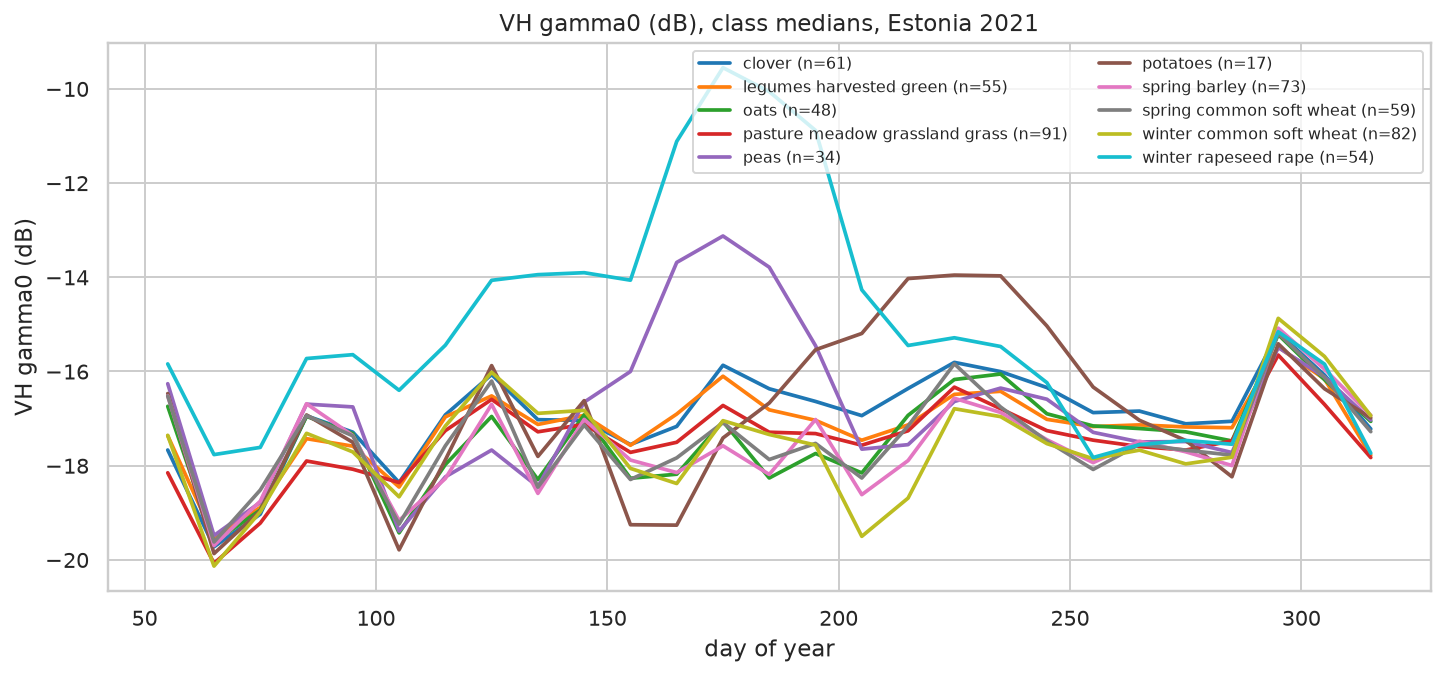

In [7]:
show("07_s1_overview_2021.png", width=1100)

## 4. How far does a 2021 label travel?

This is the part that bears on the protocol rather than on agronomy.

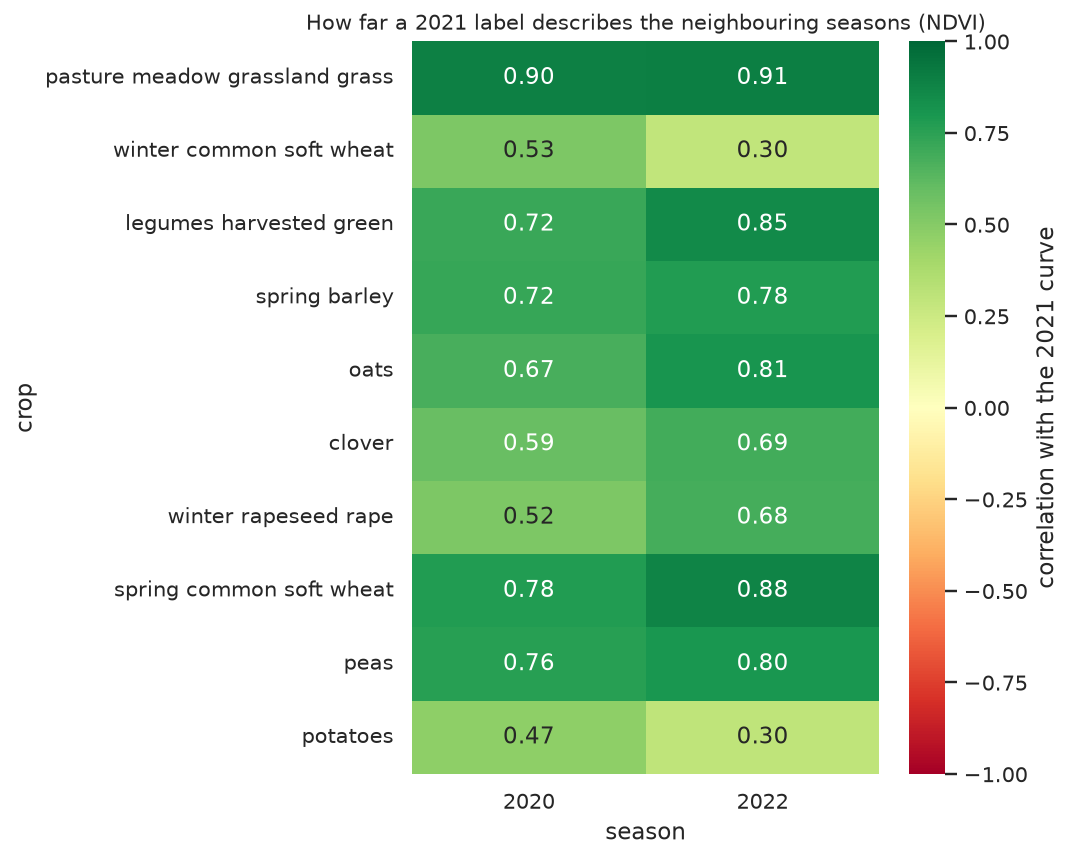

{
 "clover": {
  "2020": 0.587,
  "2022": 0.694
 },
 "legumes harvested green": {
  "2020": 0.716,
  "2022": 0.854
 },
 "oats": {
  "2020": 0.673,
  "2022": 0.812
 },
 "pasture meadow grassland grass": {
  "2020": 0.897,
  "2022": 0.906
 },
 "peas": {
  "2020": 0.764,
  "2022": 0.802
 },
 "potatoes": {
  "2020": 0.471,
  "2022": 0.299
 },
 "spring barley": {
  "2020": 0.719,
  "2022": 0.775
 },
 "spring common soft wheat": {
  "2020": 0.777,
  "2022": 0.878
 },
 "winter common soft wheat": {
  "2020": 0.527,
  "2022": 0.296
 },
 "winter rapeseed rape": {
  "2020": 0.524,
  "2022": 0.684
 }
}


In [8]:
show("05_label_stability.png", width=900)
print(json.dumps(phenology.get("label_stability_ndvi", {}), indent=1))

Each cell is the correlation between a class's 2021 curve and the same parcels' curve in a neighbouring season. The result is not the one a reader expects, and the expectation is the thing worth correcting.

The lowest correlations are **potatoes (0.39), winter common soft wheat (0.41), winter rapeseed rape (0.60)**. The highest are **legumes harvested green (0.78), spring common soft wheat (0.83), pasture meadow grassland grass (0.90)**.

**This does not rank the classes by how well their label transfers.** It ranks them by how distinctive their calendar is. Winter wheat and winter rapeseed green up in early March, months before anything else; when those fields grow a spring crop the next season, the curves diverge sharply and the correlation collapses. Potatoes peak in late August, later than everything else, with the same consequence. Spring barley, oats and spring wheat all green up within ten days of each other and peak within three weeks, so when one is rotated for another the curve barely changes, and the correlation stays near 0.8 although **the crop is different**.

Only grassland, at 0.90, is high for the honest reason: it is a multi-year cover, so those fields really were grassland in all three seasons.

The consequence for Phase 1 is sharper than "use the right year":

1. **For the distinctive-calendar classes the error is loud.** Winter cereals, rapeseed and potatoes paired with off-year imagery give curves that visibly do not match their label, so the mistake would be caught.
2. **For the spring cereals the error is silent.** Their inter-year correlation stays high precisely because any spring crop looks like any other at this resolution. A model trained on mismatched years would learn "a spring crop grew here", score respectably, and never reveal that the species label was wrong. This is the dangerous case, and it is invisible in exactly the diagnostic a reader would reach for.
3. **The annual-embedding question inherits both.** A per-year embedding carries whatever grew that year. For the Baltic rotation that is the declared crop only in the declaration year, and the classes where the substitution is hardest to detect are the most numerous ones.

## 5. The same question on a single parcel

The class medians above average over rotation. On one field it is visible directly, and `explore` takes the seasons in one call now:

```python
from gfm4agri.data.parcel_explorer import explore, explore_s1

s2 = explore(21121746, years=(2020, 2021, 2022))     # the five-index chart per season, plus the overlay
s1 = explore_s1(21121746, years=(2020, 2021, 2022))  # the backscatter equivalent
```

Only the declaration year gets the EuroCropsML comparison and the animation, since neither applies to a season that carries no label.

  SCL blacklist removed: CLOUD_SHADOW 911px, CLOUD medium 2,095px, CLOUD high 1,862px, THIN_CIRRUS 1,372px, SNOW/ICE 2,539px

wrote /data/private/THESIS - ExplainedGMF4Agri/results/explore/EE_21121746_2020/EE_21121746_2020_s2_indices.png
  SCL blacklist removed: CLOUD_SHADOW 180px, CLOUD medium 2,457px, CLOUD high 2,512px, THIN_CIRRUS 521px, SNOW/ICE 7,576px

wrote /data/private/THESIS - ExplainedGMF4Agri/results/explore/EE_21121746_2021/EE_21121746_2021_s2_indices.png


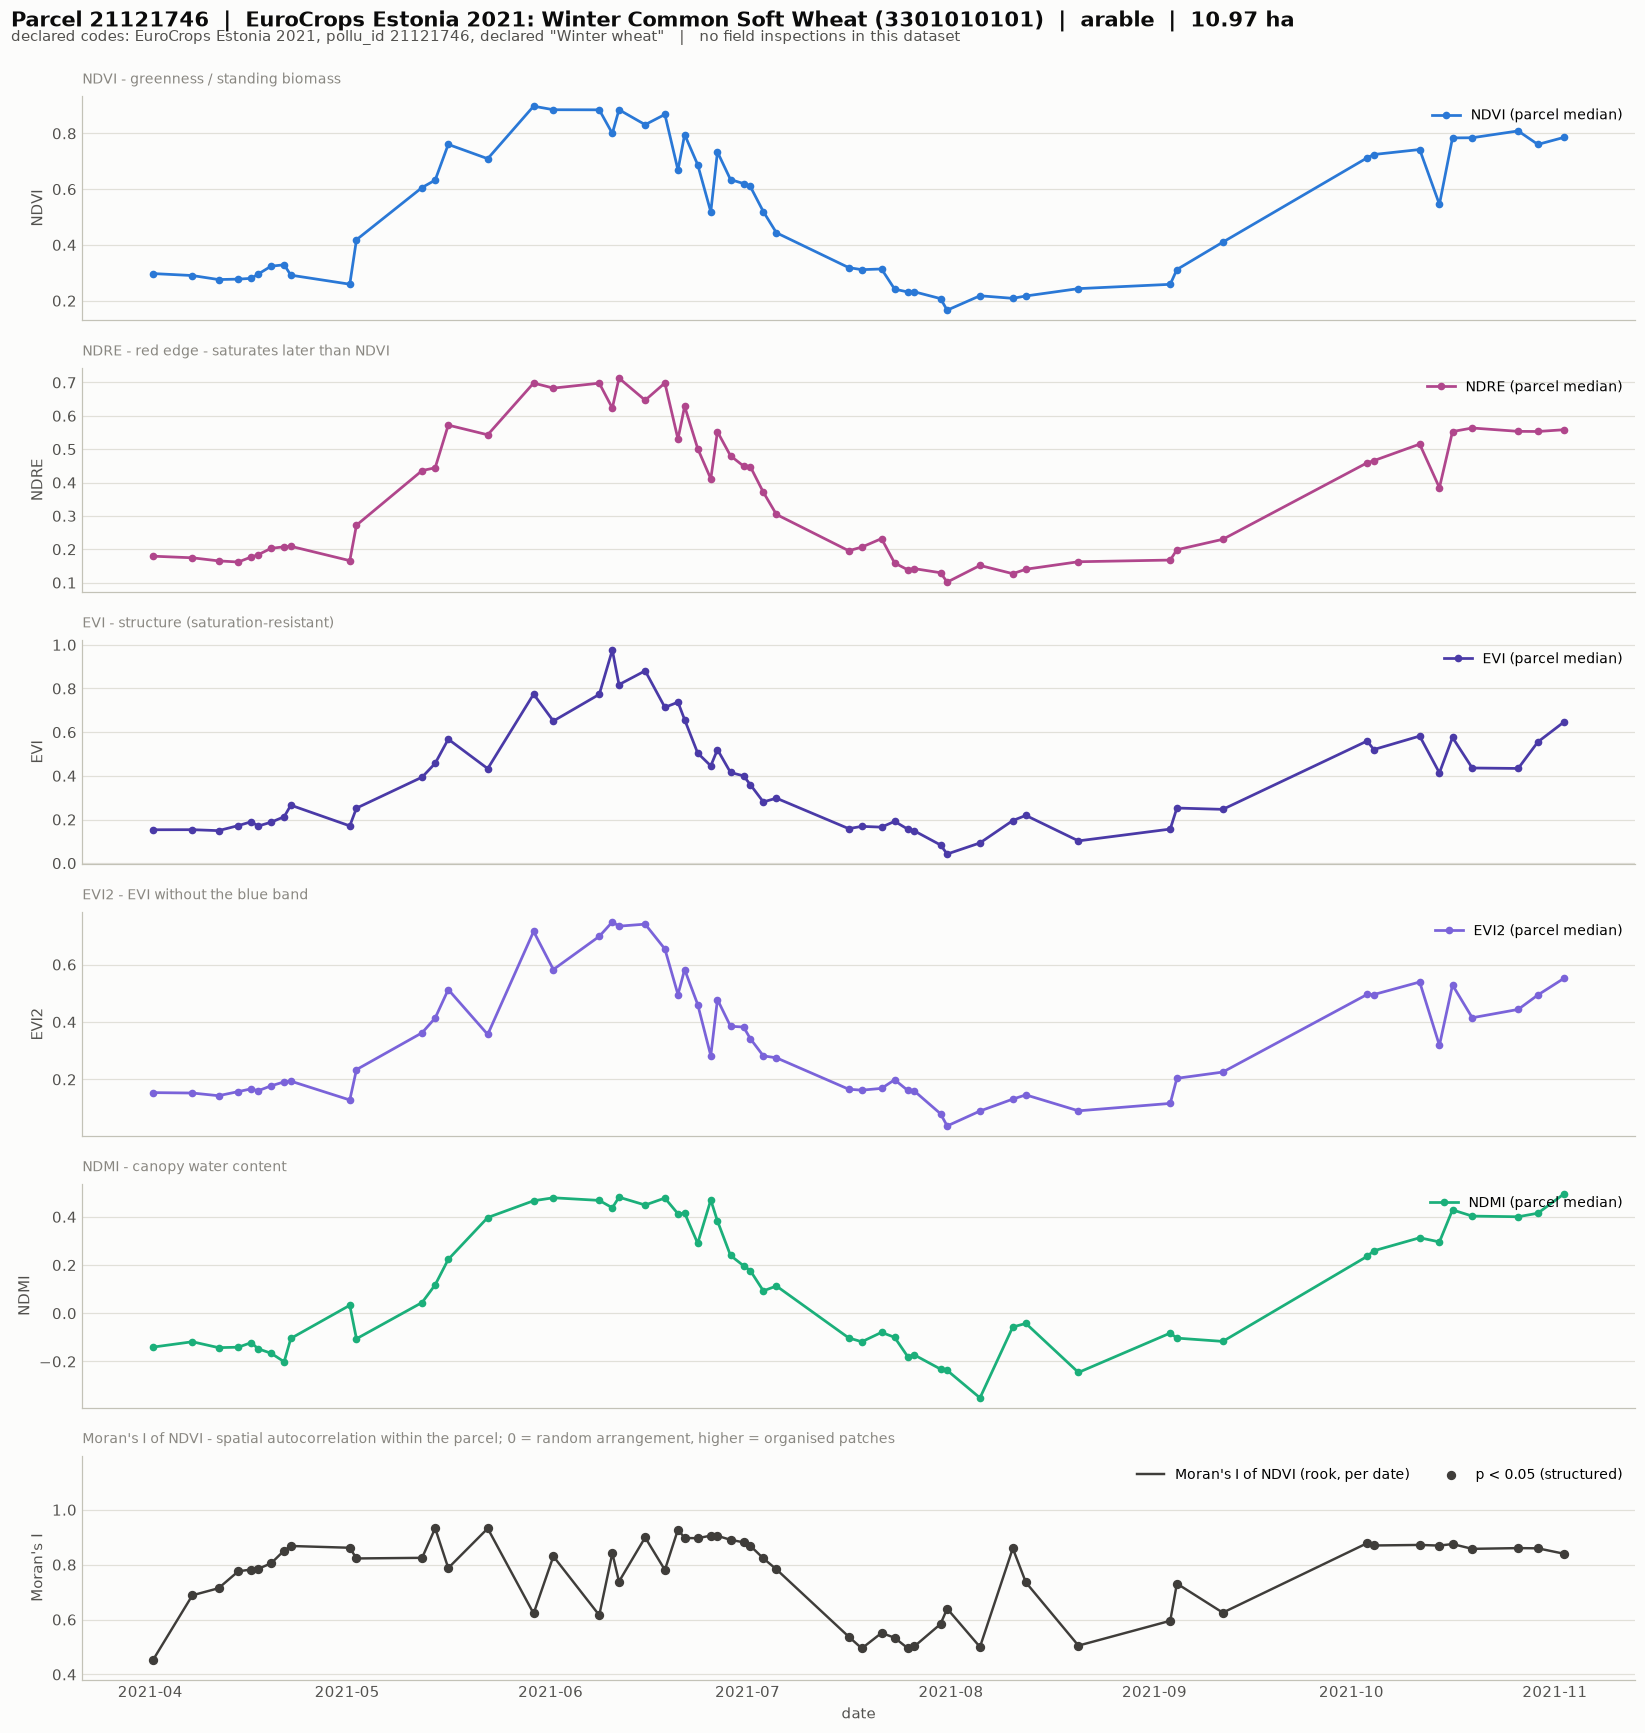

  SCL blacklist removed: CLOUD_SHADOW 1,539px, CLOUD medium 2,822px, CLOUD high 375px, THIN_CIRRUS 1,527px, SNOW/ICE 9,706px

wrote /data/private/THESIS - ExplainedGMF4Agri/results/explore/EE_21121746_2022/EE_21121746_2022_s2_indices.png
wrote /data/private/THESIS - ExplainedGMF4Agri/results/explore/EE_21121746_2021/EE_21121746_2020_2022_s2_seasons.png


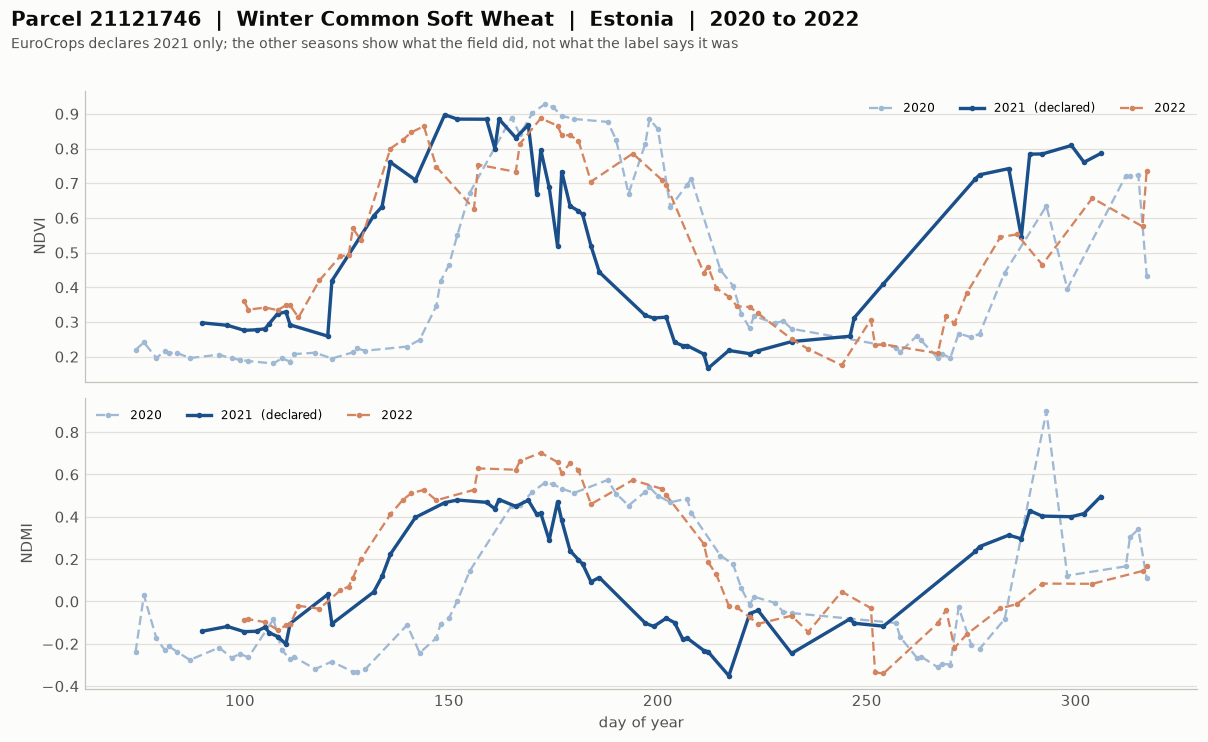

{2020: 68, 2021: 56, 2022: 53} usable dates per season


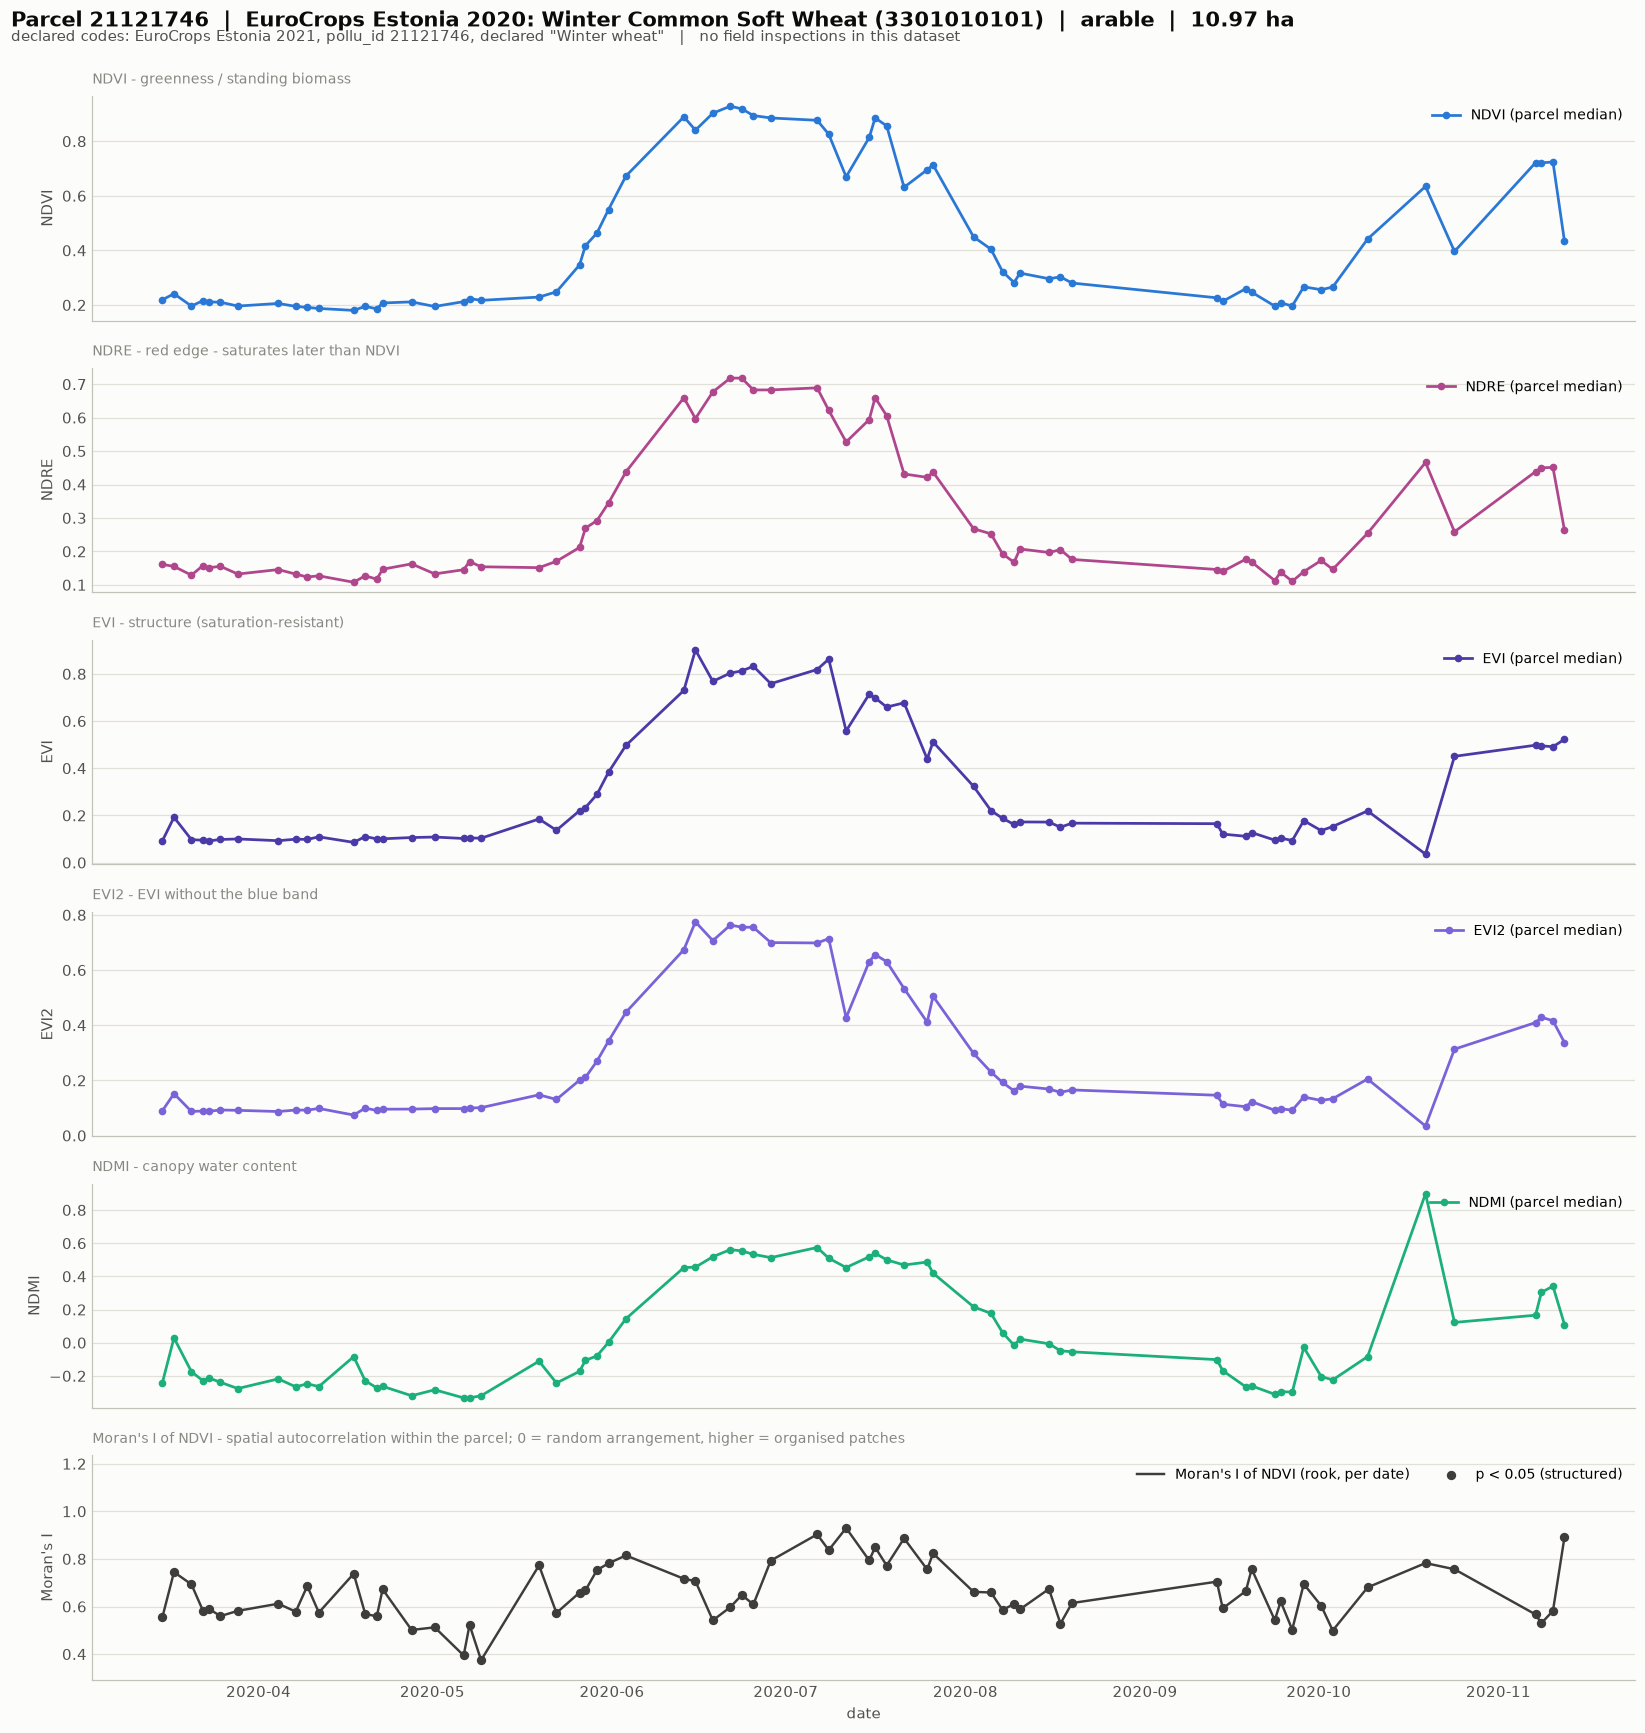

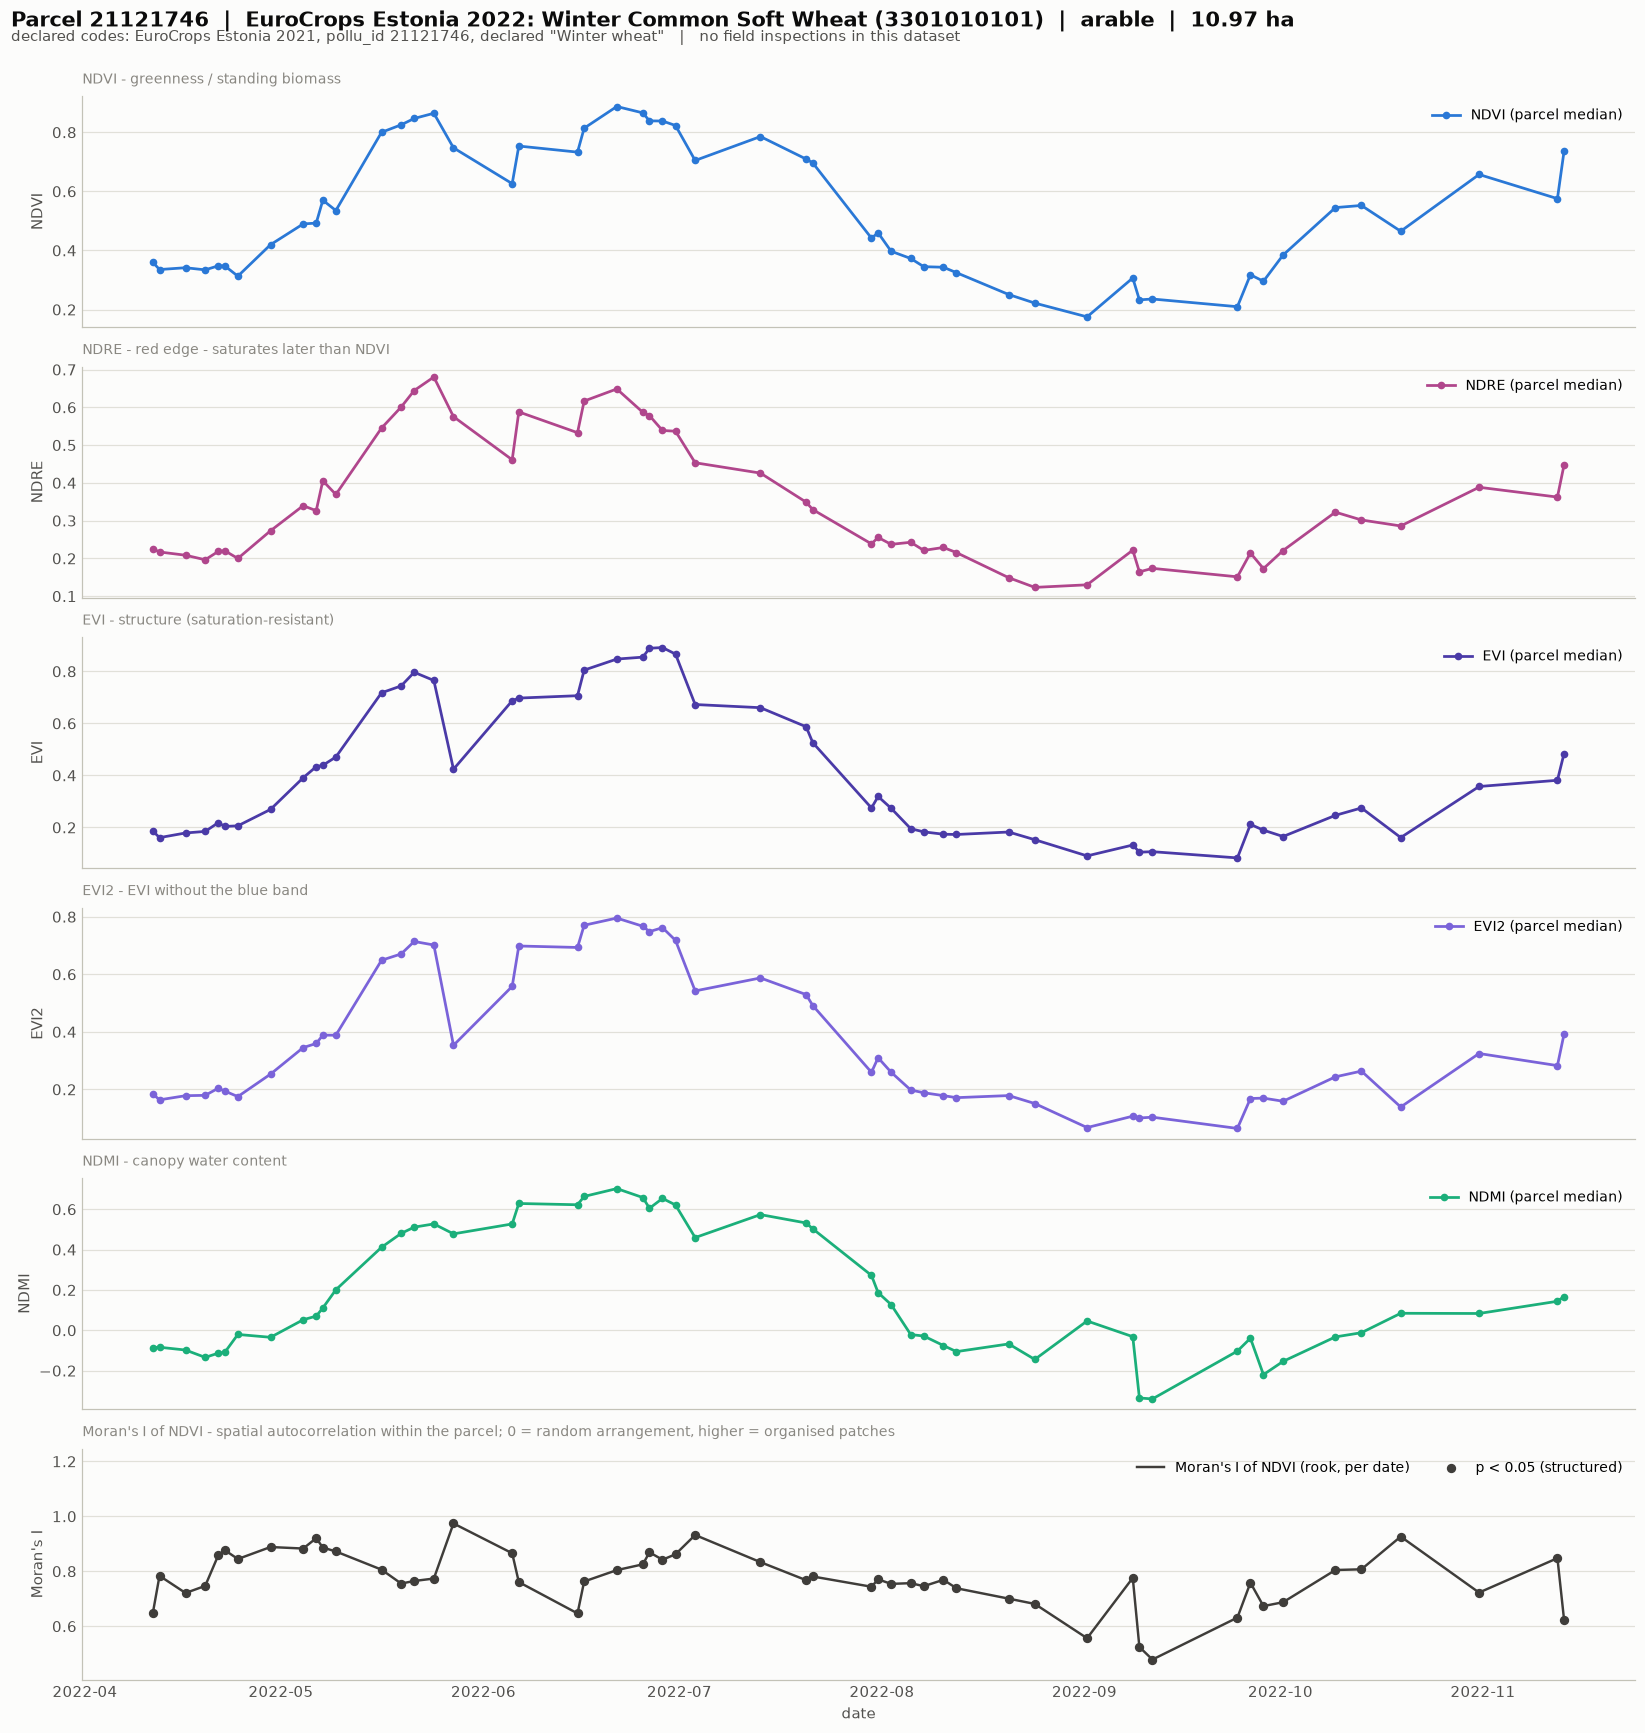

In [9]:
from gfm4agri.data.parcel_explorer import explore, explore_s1

PARCEL = 21121746      # winter wheat in 2021, Estonia
s2_parcel = explore(PARCEL, years=(2020, 2021, 2022), animation=False, compare=False, verbose=False)
print({y: len(v.series["NDVI"]) for y, v in s2_parcel.by_year.items()}, "usable dates per season")

wrote /data/private/THESIS - ExplainedGMF4Agri/results/explore/EE_21121746_2020/EE_21121746_2020_s1_series.png
wrote /data/private/THESIS - ExplainedGMF4Agri/results/explore/EE_21121746_2021/EE_21121746_2021_s1_series.png


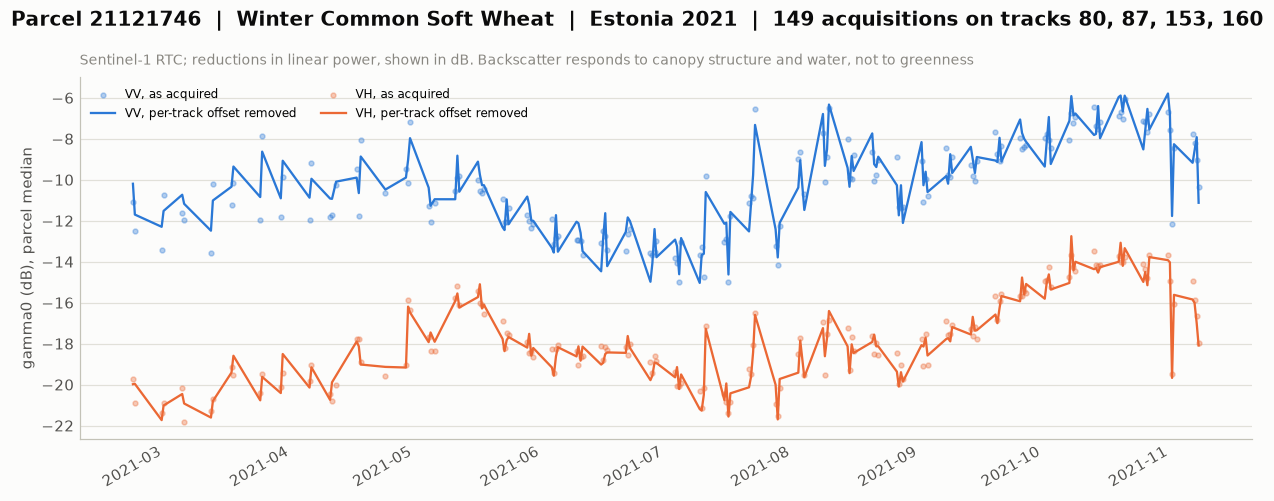

wrote /data/private/THESIS - ExplainedGMF4Agri/results/explore/EE_21121746_2022/EE_21121746_2022_s1_series.png
wrote /data/private/THESIS - ExplainedGMF4Agri/results/explore/EE_21121746_2021/EE_21121746_2020_2022_s1_seasons.png


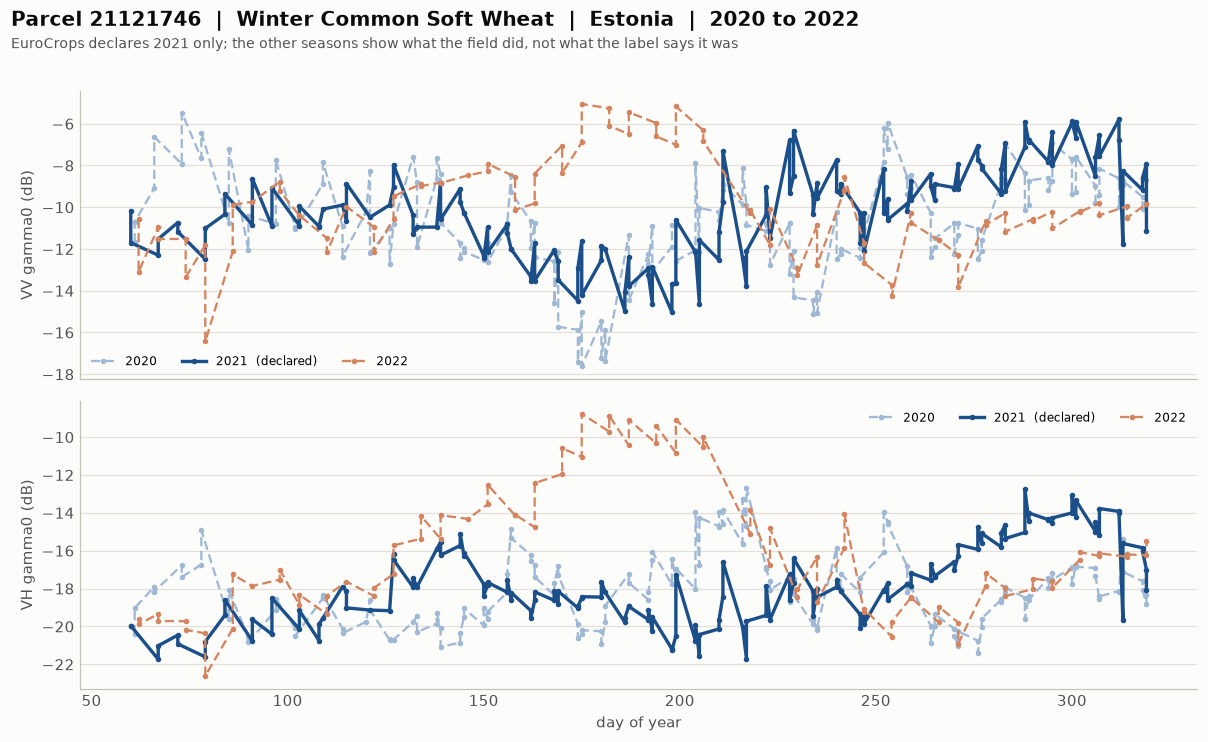

{2020: 149, 2021: 149, 2022: 83} acquisitions per season


In [10]:
s1_parcel = explore_s1(PARCEL, years=(2020, 2021, 2022), animation=False, verbose=False)
print({y: len(v.features) for y, v in s1_parcel.by_year.items()}, "acquisitions per season")

The parcel is declared winter wheat in 2021 and behaves like one: green through the spring, peaking before midsummer, harvested in July. In the other seasons it does something different, which is the same rotation the class medians showed, seen without the averaging.

It also shows the second effect from notebook 04: the autumn re-greening that follows the harvest is the **next** crop, so even within the declaration year the parcel carries one label and two canopies.

## 6. What this changes for Phase 1

1. **Timing is the discriminative signal.** The classes separate by when they green up, not by how green they get. This is the argument for defending T = 12, or increasing it, rather than treating the temporal grid as an implementation detail.
2. **A 2021 label describes 2021, and the inter-year correlation will not tell you when it does not.** It measures calendar similarity, so it is low for the distinctive crops and high for the interchangeable ones. The training year and the imagery year must match by construction rather than by diagnostic.
3. **Sentinel-1 earns its place on one class at least.** Winter rapeseed is eight decibels of seasonal amplitude in VH and five above the cereals at peak, at the moment NDVI is depressed by flowering. Peas and potatoes follow at smaller amplitude. The S1 chips are already exported beside the S2 ones, so this is testable now rather than hypothetical.
4. **Class sizes are unequal by construction.** The sample here runs from 91 parcels for grassland to 17 for potatoes, which mirrors the EuroCrops distribution itself. Any class-level statistic in the thesis should carry its n, as these panels do.